# Hand Gesture Recognition - 02: Transfer Learning

Frozen ImageNet ResNet18 -> 512-d features -> logistic regression (stratified 70/30 split). No CNN fine-tuning.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
from sklearn.model_selection import train_test_split
device=utils.get_device(); print('device:',device)
imgs,labels,classes=utils.load_sample(); print(len(imgs),'images,',len(classes),'classes')

device: mps
900 images, 3 classes


## 1. Extract features

In [2]:
net=utils.build_extractor(device)
X=utils.extract_features(net,imgs,device)
y=np.array(labels); print('feature matrix:',X.shape)

feature matrix: (900, 512)


## 2. Train + evaluate

In [3]:
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
clf=utils.train_classifier(Xtr,ytr)
acc,cm,preds=utils.evaluate(clf,Xte,yte,classes)
print('TEST ACCURACY: %.4f  (%d / %d)'%(acc,int(round(acc*len(yte))),len(yte)))

TEST ACCURACY: 1.0000  (270 / 270)


## 3. Confusion matrix

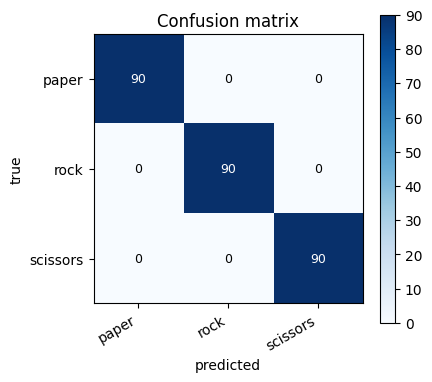

In [4]:
plt.figure(figsize=(4.5,4)); plt.imshow(cm,cmap='Blues'); plt.colorbar()
plt.xticks(range(len(classes)),classes,rotation=30,ha='right'); plt.yticks(range(len(classes)),classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j,i,cm[i,j],ha='center',va='center',fontsize=9,color='black' if cm[i,j]<cm.max()/2 else 'white')
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Confusion matrix'); plt.tight_layout(); plt.show()

## 4. Per-class accuracy

In [5]:
for i,cls in enumerate(classes):
    tot=cm[i].sum()
    if tot: print('%-16s %.2f (%d/%d)'%(cls,cm[i,i]/tot,cm[i,i],tot))

paper            1.00 (90/90)
rock             1.00 (90/90)
scissors         1.00 (90/90)


## 5. Sample predictions (red = wrong)

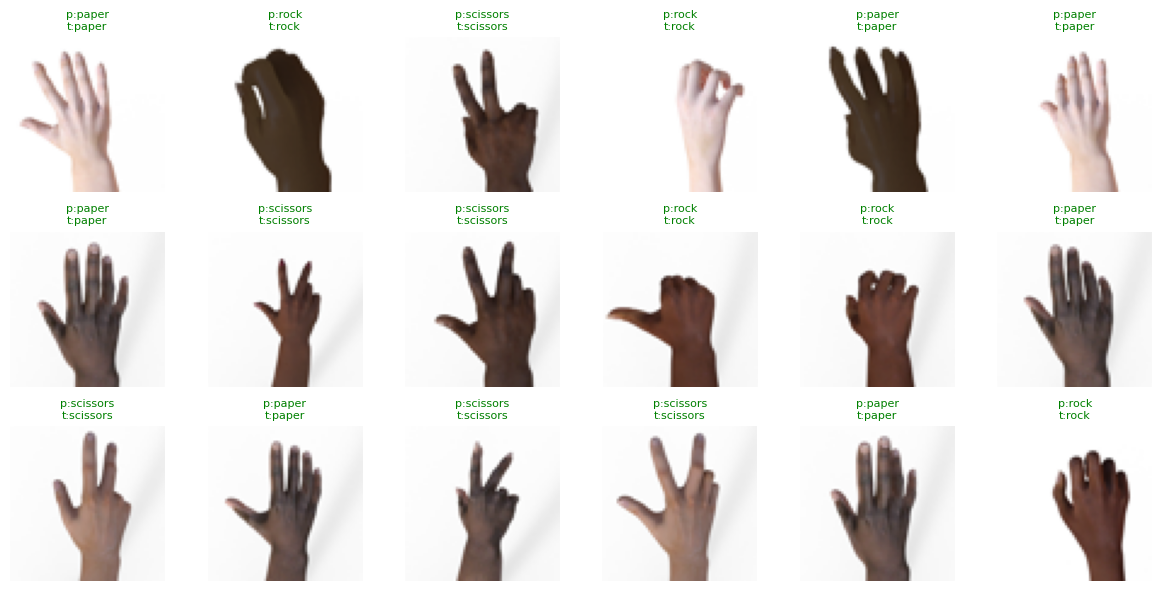

In [6]:
idx=np.arange(len(imgs))
from sklearn.model_selection import train_test_split as tts
_,te=tts(idx,test_size=0.3,random_state=42,stratify=y)
show=te[:18]
fig,ax=plt.subplots(3,6,figsize=(12,6))
for a,i in zip(ax.ravel(),show):
    a.imshow(imgs[i]); a.axis('off'); pr=clf.predict(X[i:i+1])[0]
    a.set_title('p:%s\nt:%s'%(pr,y[i]),color='green' if pr==y[i] else 'red',fontsize=8)
plt.tight_layout(); plt.show()

### Findings
Frozen ResNet18 features + logistic regression classify the three gestures at high accuracy (see the printed number). Hand shape is distinctive enough that the frozen features separate the gestures; residual confusion is mostly scissors vs paper at awkward angles.